# Phase 2 · 3단원 — 로지스틱 회귀

> **이름은 '회귀'인데 사실은 분류입니다. "예/아니오"를 맞히는 가장 기본적인 방법이에요.**

- 원문: <https://aiengineeringfromscratch.com/lesson?path=phases/02-ml-fundamentals/03-logistic-regression>
- 예상 시간: 90분 · 선수 지식: 1~2단원

---

## 📌 출처 표시 규칙

> 📗 **원문** — 커리큘럼에 있는 내용입니다.

> ✨ **추가** — 원문에는 없고, 제가 넣은 비유·예시·실험입니다.

---

## 🎯 이 단원에서 배우는 것

> 📗 **원문** — "Learning Objectives"

1. **왜 선형 회귀로는 분류를 못 하는지** 이해합니다.
2. **시그모이드 함수**로 숫자를 확률로 바꿉니다.
3. **크로스 엔트로피**라는 새 채점 방법을 배웁니다.
4. **정밀도·재현율·F1** 같은 평가 지표를 직접 계산합니다.

### 🔑 2단원과 무엇이 같고 무엇이 다른가

| | 2단원 (선형 회귀) | 3단원 (로지스틱 회귀) |
| --- | --- | --- |
| 답의 모양 | 숫자 (집값) | **예/아니오** |
| 모델 | `y = wx + b` | `wx + b` 에 **시그모이드를 씌움** |
| 채점(비용) | MSE | **크로스 엔트로피** |
| 학습 방법 | 경사하강법 | **똑같이 경사하강법** |

> **바뀌는 건 두 군데뿐입니다.** 마지막에 시그모이드를 씌우는 것, 그리고 채점 방법.
> **나머지는 2단원과 완전히 같습니다.**

---

## 📖 목차

| # | 내용 | 출처 |
| --- | --- | --- |
| 0 | 왜 선형 회귀로는 안 될까 | 📗 원문 + ✨ 실험 |
| 1 | 🔑 시그모이드 — 숫자를 확률로 바꾸는 마법 | 📗 원문 + ✨ 그림 |
| 2 | 로지스틱 회귀 = 직선 + 시그모이드 | 📗 원문 |
| 3 | 크로스 엔트로피 — 새로운 채점 방법 | 📗 원문 + ✨ 실험 |
| 4 | 왜 MSE를 쓰면 안 되나 | 📗 원문 + ✨ 그림 |
| 5 | 🔨 직접 만들어 보기 | 📗 원문 |
| 6 | 결정 경계 | 📗 원문 |
| 7 | 혼동 행렬 · 정밀도 · 재현율 · F1 | 📗 원문 + ✨ 비유 |
| 8 | 임곗값 조절하기 | 📗 원문 |
| 9 | 여러 종류로 나누기 (소프트맥스) | 📗 원문 |
| 10 | 용어 사전 · 연습문제 | 📗 원문 |

---

## 🗺️ 이 단원은 이렇게 이어집니다

> ✨ **추가** — 절이 왜 이 순서인지 먼저 짚고 갑니다. 하나가 다음 하나를 불러옵니다.

**0절**에서 2단원의 선형 회귀를 그대로 분류에 써 봅니다. 그리고 **망합니다.**
직선은 $-\infty$에서 $+\infty$까지 뻗는데, 우리가 원하는 건 **0과 1 사이의 확률**이거든요.

이 어긋남을 메우는 게 이 단원의 전부입니다. 순서대로 세 개를 고칩니다.

- **1절 🔑 시그모이드** — 첫 번째 수리. **무한한 숫자를 0~1로 눌러 담는 압축기**를 끼웁니다.
- **2절** — 그래서 로지스틱 회귀 = **직선(2단원) + 시그모이드(1절)** 입니다. 정말 이게 전부예요.
- **3절 크로스 엔트로피** — 두 번째 수리. 출력이 확률로 바뀌었으니 **채점 방법도 바뀌어야** 합니다.
- **4절** — 그런데 왜 굳이 새 채점법을 만들죠? **MSE를 그냥 쓰면 안 되나요?**
  **여기가 3절의 이유입니다.** 안 되는 걸 눈으로 보여 드립니다.
- **5절 🔨** — 세 조각(직선 + 시그모이드 + 크로스 엔트로피)을 합쳐 **직접 만듭니다.**

만들고 나면 새로운 질문이 줄줄이 나옵니다.

- **6절 결정 경계** — 만든 모델은 결국 **어디에 선을 그은 걸까요?** 그림으로 확인합니다.
- **7절 혼동 행렬·정밀도·재현율** — 세 번째 수리. **정확도 하나로는 부족합니다.**
  암 환자 1%를 전부 "정상"이라 해도 정확도 99%가 나오거든요.
- **8절 임곗값** — 7절에서 본 **정밀도와 재현율의 맞바꿈을 직접 조종**합니다.
  0.5는 그냥 기본값일 뿐, 상황에 따라 옮겨야 합니다.
- **9절 소프트맥스** — 여기까지 전부 **둘 중 하나**였습니다. 셋 이상이면 시그모이드를 확장합니다.

### 한 줄로 꿰면

> **직선으론 확률이 안 나온다(0) → 시그모이드로 눌러 담고(1·2) → 채점법도 바꾸고(3)
> → 왜 바꿔야 했는지 확인하고(4) → 만들고(5) → 어디에 선을 그었나 보고(6)
> → 정확도만으론 부족함을 알고(7) → 임곗값으로 조절하고(8) → 셋 이상으로 넓히기(9)**

In [1]:
# ── 준비물 ──────────────────────────────────────────────────────
import math
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

np.set_printoptions(precision=3, suppress=True)

available = {f.name for f in fm.fontManager.ttflist}
for cand in ["Apple SD Gothic Neo", "AppleGothic", "NanumGothic",
             "NanumBarunGothicOTF", "Malgun Gothic", "Noto Sans CJK KR"]:
    if cand in available:
        matplotlib.rcParams["font.family"] = ["DejaVu Sans", cand]
        break
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["figure.dpi"] = 110

print("준비 끝!")

준비 끝!


## 0️⃣ 왜 선형 회귀로는 안 될까

> 📗 **원문** — "Why Linear Regression Fails for Classification"

공부 시간으로 **합격(1) / 불합격(0)** 을 맞혀 봅시다.

```
공부시간:  1   2   3   4   5   6   7   8   9   10
결과:      0   0   0   0   1   1   1   1   1   1
```

2단원에서 배운 직선을 그대로 쓰면 어떻게 될까요?

### 문제 ① — 확률이 아닌 값이 나옵니다

직선은 **아무 숫자나** 낼 수 있습니다. 1시간에 **−0.2**, 10시간에 **1.3** 같은 값이요.

> **−20% 확률로 합격? 130% 확률로 합격?**
>
> 말이 안 됩니다. 확률은 **0과 1 사이**여야 해요.

### 문제 ② — 이상치 하나에 무너집니다

누가 **50시간** 공부했다고 해 봅시다. 직선 전체가 그쪽으로 끌려가서
**나머지 사람들의 예측까지 전부 망가집니다.**

### 그래서 필요한 것

분류에는 이런 함수가 필요합니다.

1. 출력이 **항상 0과 1 사이** (= 확률)
2. **딱 갈라지는 지점**이 있음 (= 결정 경계)
3. 멀리 있는 **이상치에 흔들리지 않음**

> ✨ **추가 실험** — 직선을 그대로 써 보고 정말 문제가 생기는지 확인합니다.

In [2]:
# 공부 시간과 합격 여부 (원문 예시 그대로)
시간 = np.array([1., 2, 3, 4, 5, 6, 7, 8, 9, 10])
합격 = np.array([0., 0, 0, 0, 1, 1, 1, 1, 1, 1])

# 2단원에서 배운 정규방정식으로 직선을 구합니다
def 직선맞추기(x, y):
    A = np.c_[np.ones(len(x)), x]
    b_, w_ = np.linalg.solve(A.T @ A, A.T @ y)
    return w_, b_

w선형, b선형 = 직선맞추기(시간, 합격)
print(f"직선으로 맞춘 결과: y = {w선형:.4f}x + {b선형:.4f}\n")
print(f"{'공부시간':>10}{'실제':>8}{'직선의 예측':>14}{'문제':>26}")
print("-" * 60)
for t in [1, 3, 5, 8, 10]:
    예측 = w선형 * t + b선형
    문제 = "❌ 0보다 작음!" if 예측 < 0 else ("❌ 1보다 큼!" if 예측 > 1 else "")
    실제 = 합격[list(시간).index(t)]
    print(f"{t:>10}{실제:>8.0f}{예측:>14.4f}{문제:>26}")

print("\n=> 확률이라면서 음수가 나옵니다. 이건 해석 자체가 불가능합니다.")

print("\n【 이상치 한 명을 추가하면? 】")
시간2 = np.append(시간, 50.0)      # 50시간 공부한 사람
합격2 = np.append(합격, 1.0)
w2, b2 = 직선맞추기(시간2, 합격2)
print(f"  이상치 전: y = {w선형:.4f}x + {b선형:.4f}")
print(f"  이상치 후: y = {w2:.4f}x + {b2:.4f}")
print(f"\n  5시간 공부한 사람의 예측값:")
print(f"    이상치 전 {w선형*5+b선형:.3f}  ->  합격 (0.5 넘음)")
print(f"    이상치 후 {w2*5+b2:.3f}  ->  불합격 (0.5 못 넘음)  ❌ 판정이 뒤집혔습니다!")
print("\n  => 나와 상관없는 사람 한 명 때문에 내 결과가 바뀌었습니다.")

직선으로 맞춘 결과: y = 0.1455x + -0.2000

      공부시간      실제        직선의 예측                        문제
------------------------------------------------------------
         1       0       -0.0545                 ❌ 0보다 작음!
         3       0        0.2364                          
         5       1        0.5273                          
         8       1        0.9636                          
        10       1        1.2545                  ❌ 1보다 큼!

=> 확률이라면서 음수가 나옵니다. 이건 해석 자체가 불가능합니다.

【 이상치 한 명을 추가하면? 】
  이상치 전: y = 0.1455x + -0.2000
  이상치 후: y = 0.0150x + 0.4935

  5시간 공부한 사람의 예측값:
    이상치 전 0.527  ->  합격 (0.5 넘음)
    이상치 후 0.568  ->  불합격 (0.5 못 넘음)  ❌ 판정이 뒤집혔습니다!

  => 나와 상관없는 사람 한 명 때문에 내 결과가 바뀌었습니다.


## 1️⃣ 🔑 시그모이드 — 숫자를 확률로 바꾸는 마법

> 🔗 **앞 절과 이어서** — 0절에서 문제를 봤습니다. 직선의 출력은 **아무 값이나** 나오는데,
> 우리가 원하는 건 **0과 1 사이의 확률**입니다.
> 그럼 **직선의 출력을 0~1로 눌러 담는 장치**를 하나 끼우면 되지 않을까요?

> 📗 **원문** — "The Sigmoid Function"

**시그모이드 함수**가 위의 세 가지 요구를 정확히 만족합니다.

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

### 🧸 이 함수가 하는 일

> **어떤 숫자를 넣든 0과 1 사이로 눌러 담습니다.**

- `z`가 **아주 큰 양수** → 1에 가까워짐
- `z`가 **아주 큰 음수** → 0에 가까워짐
- `z = 0` → **정확히 0.5**

### 🧸 비유 — 압축기

숫자 직선은 `−∞`부터 `+∞`까지 무한히 뻗어 있습니다.
시그모이드는 이 무한한 직선을 **0과 1 사이 짧은 구간에 꾹 눌러 담는 압축기**예요.

- 가운데(z=0 근처)는 **덜 눌립니다** → 변화가 민감함
- 양 끝은 **아주 세게 눌립니다** → z가 10이든 100이든 결과는 거의 1

**이게 이상치에 강한 이유입니다.** 50시간 공부한 사람이든 500시간이든
시그모이드를 통과하면 둘 다 "거의 1"이 되어 버려서 영향력이 제한됩니다.

### 📐 편리한 성질 하나

미분하면 이렇게 됩니다.

$$\sigma'(z) = \sigma(z)\big(1 - \sigma(z)\big)$$

**자기 자신으로 미분이 표현됩니다.** 그래서 기울기 계산이 아주 빨라요.
(지금은 "편리하구나" 정도만 알아 두시면 됩니다)

In [3]:
def 시그모이드(z):
    # 아주 큰 음수에서 exp가 폭발하지 않게 안전하게 계산합니다
    return np.where(z >= 0,
                    1 / (1 + np.exp(-np.clip(z, -500, 500))),
                    np.exp(np.clip(z, -500, 500)) / (1 + np.exp(np.clip(z, -500, 500))))

print("어떤 숫자를 넣어도 0과 1 사이가 나옵니다\n")
print(f"{'넣은 값 z':>14}{'시그모이드 결과':>18}{'해석':>24}")
print("-" * 58)
for z in [-100, -10, -2, -1, 0, 1, 2, 10, 100]:
    p = float(시그모이드(np.array([float(z)]))[0])
    if p < 0.1:
        해석 = "거의 확실히 0번"
    elif p < 0.45:
        해석 = "0번 쪽"
    elif p < 0.55:
        해석 = "반반 (경계)"
    elif p < 0.9:
        해석 = "1번 쪽"
    else:
        해석 = "거의 확실히 1번"
    print(f"{z:>14}{p:>18.6f}{해석:>24}")

print("\n=> z = -100 이든 -1000 이든 결과는 거의 0입니다. 더 내려갈 곳이 없어요.")
print("   이게 '이상치에 강하다'는 말의 뜻입니다.")
print("\n💡 z = 0 일 때 정확히 0.5가 나옵니다. 이 지점이 '결정 경계'가 됩니다 (6절).")

어떤 숫자를 넣어도 0과 1 사이가 나옵니다

        넣은 값 z          시그모이드 결과                      해석
----------------------------------------------------------
          -100          0.000000               거의 확실히 0번
           -10          0.000045               거의 확실히 0번
            -2          0.119203                    0번 쪽
            -1          0.268941                    0번 쪽
             0          0.500000                 반반 (경계)
             1          0.731059                    1번 쪽
             2          0.880797                    1번 쪽
            10          0.999955               거의 확실히 1번
           100          1.000000               거의 확실히 1번

=> z = -100 이든 -1000 이든 결과는 거의 0입니다. 더 내려갈 곳이 없어요.
   이게 '이상치에 강하다'는 말의 뜻입니다.

💡 z = 0 일 때 정확히 0.5가 나옵니다. 이 지점이 '결정 경계'가 됩니다 (6절).


> ✨ **추가 그림** — 시그모이드의 모양과, 직선과의 차이를 봅시다.

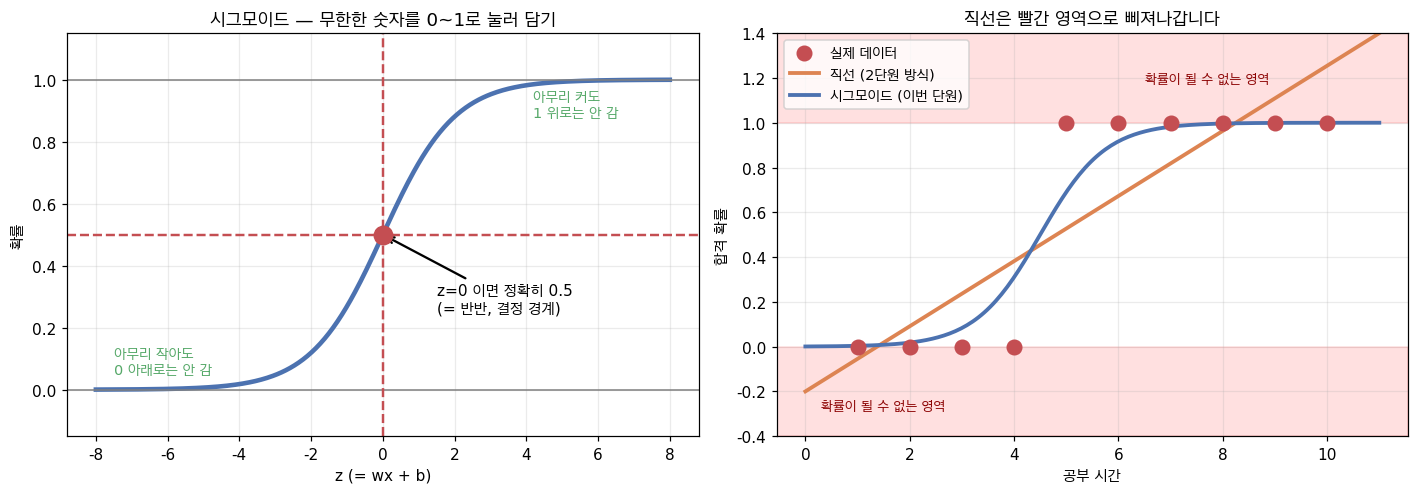

오른쪽 그림에서 주황 직선은 빨간 영역(불가능한 확률)으로 나갑니다.
파란 시그모이드는 절대 나가지 않습니다. S자로 부드럽게 눕죠.


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))

# 왼쪽: 시그모이드 모양
zs = np.linspace(-8, 8, 400)
ax1.plot(zs, 시그모이드(zs), lw=3, color="#4c72b0")
ax1.axhline(0, color="gray", lw=1); ax1.axhline(1, color="gray", lw=1)
ax1.axhline(0.5, color="#c44e52", ls="--", lw=1.6)
ax1.axvline(0, color="#c44e52", ls="--", lw=1.6)
ax1.plot(0, 0.5, "o", ms=12, color="#c44e52", zorder=5)
ax1.annotate("z=0 이면 정확히 0.5\n(= 반반, 결정 경계)", (0, 0.5), xytext=(1.5, 0.25),
             fontsize=10, arrowprops=dict(arrowstyle="->", lw=1.5))
ax1.text(-7.5, 0.05, "아무리 작아도\n0 아래로는 안 감", fontsize=9.5, color="#55a868")
ax1.text(4.2, 0.88, "아무리 커도\n1 위로는 안 감", fontsize=9.5, color="#55a868")
ax1.set_xlabel("z (= wx + b)"); ax1.set_ylabel("확률")
ax1.set_title("시그모이드 — 무한한 숫자를 0~1로 눌러 담기", fontsize=12)
ax1.set_ylim(-0.15, 1.15); ax1.grid(alpha=0.25)

# 오른쪽: 직선 vs 시그모이드 비교
ax2.scatter(시간, 합격, s=90, color="#c44e52", zorder=5, label="실제 데이터")
ts = np.linspace(0, 11, 200)
ax2.plot(ts, w선형 * ts + b선형, lw=2.5, color="#dd8452", label="직선 (2단원 방식)")
ax2.plot(ts, 시그모이드(1.6 * (ts - 4.5)), lw=2.5, color="#4c72b0",
         label="시그모이드 (이번 단원)")
ax2.axhspan(-0.4, 0, color="red", alpha=0.12)
ax2.axhspan(1, 1.4, color="red", alpha=0.12)
ax2.text(0.3, -0.28, "확률이 될 수 없는 영역", fontsize=9, color="darkred")
ax2.text(6.5, 1.18, "확률이 될 수 없는 영역", fontsize=9, color="darkred")
ax2.set_xlabel("공부 시간"); ax2.set_ylabel("합격 확률")
ax2.set_title("직선은 빨간 영역으로 삐져나갑니다", fontsize=12)
ax2.set_ylim(-0.4, 1.4); ax2.legend(fontsize=9.5); ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("오른쪽 그림에서 주황 직선은 빨간 영역(불가능한 확률)으로 나갑니다.")
print("파란 시그모이드는 절대 나가지 않습니다. S자로 부드럽게 눕죠.")

## 2️⃣ 로지스틱 회귀 = 직선 + 시그모이드

> 🔗 **앞 절과 이어서** — 재료 두 개가 모였습니다.
> **2단원의 직선**과 **1절의 시그모이드**. 이 둘을 이어 붙이면 로지스틱 회귀입니다.

> 📗 **원문** — "Logistic Regression = Linear Model + Sigmoid"

모델은 **딱 두 단계**입니다.

```
   입력 x
     ↓
  ① z = wx + b          ← 2단원과 똑같습니다!
     ↓
  ② p = 시그모이드(z)    ← 이것만 추가됐습니다
     ↓
  ③ p ≥ 0.5 이면 "1번", 아니면 "0번"
```

### 🔑 나온 값 `p`의 의미

`p`는 그냥 숫자가 아니라 **"1번 그룹일 확률"** 입니다.

- `p = 0.9` → "90% 확신하고 1번입니다"
- `p = 0.5` → "모르겠습니다, 반반이에요"
- `p = 0.1` → "90% 확신하고 0번입니다"

> 💡 **이게 큰 장점입니다.** 그냥 "1번!"이라고만 하는 게 아니라
> **얼마나 확신하는지**까지 알려 줍니다.
> 의료 진단처럼 "확실하지 않으면 사람이 다시 보게" 하고 싶을 때 아주 중요해요.

### 🔑 결정 경계

`p = 0.5`가 되는 지점, 즉 **`wx + b = 0`** 인 곳이 두 그룹을 가르는 선입니다.
(6절에서 자세히 봅니다)

## 3️⃣ 크로스 엔트로피 — 새로운 채점 방법

> 🔗 **앞 절과 이어서** — 2절에서 모델의 출력이 **확률**로 바뀌었습니다.
> 그럼 채점 방법도 바뀌어야 합니다. 2단원의 MSE는 **숫자를 맞히는** 문제용이었거든요.
> **확률을 채점하는 방법**은 뭘까요?

> 📗 **원문** — "Binary Cross-Entropy Loss"

이제 **"얼마나 틀렸나"를 재는 방법**이 필요합니다. 2단원의 MSE는 못 씁니다(4절에서 이유 설명).

대신 **이진 크로스 엔트로피(로그 손실)** 를 씁니다.

$$\text{손실} = -\frac{1}{n}\sum \Big[ y\log(p) + (1-y)\log(1-p) \Big]$$

### 🧸 무섭게 생겼지만 사실 아주 단순합니다

정답 `y`는 0 아니면 1이니까, **둘 중 하나만 살아남습니다.**

**정답이 1일 때** (`y=1`이면 뒤쪽 항이 0이 됨):

$$\text{손실} = -\log(p)$$

**정답이 0일 때** (`y=0`이면 앞쪽 항이 0이 됨):

$$\text{손실} = -\log(1-p)$$

### 🧸 한 문장으로

> **"맞는 답에 몇 %를 줬는지 보고, 그 값에 `−log`를 씌운다."**

- 정답에 **0.99**를 줬다 → `−log(0.99) = 0.01` → **벌점 거의 없음** ✅
- 정답에 **0.5**를 줬다 → `−log(0.5) = 0.69` → 보통 벌점
- 정답에 **0.01**를 줬다 → `−log(0.01) = 4.6` → **벌점 폭탄** ❌

### 🔑 왜 하필 `−log`인가

**자신 있게 틀리는 걸 아주 세게 벌주기 위해서**입니다.

정답에 0.001을 줬다면 벌점이 6.9입니다. 0.0001이면 9.2고요.
**확신에 차서 틀릴수록 벌점이 무한대로 갑니다.**

> 💡 "모르겠으면 차라리 0.5라고 말해라"를 가르치는 셈입니다.

In [5]:
# ✨ 추가 — 정답에 얼마를 줬을 때 벌점이 얼마인지 표로 봅니다
print("정답 쪽에 얼마의 확률을 줬는가 -> 벌점\n")
print(f"{'정답에 준 확률':>16}{'벌점 (-log p)':>18}{'느낌':>24}")
print("-" * 60)
for p in [0.999, 0.99, 0.9, 0.7, 0.5, 0.3, 0.1, 0.01, 0.001]:
    벌점 = -math.log(p)
    느낌 = ("거의 만점" if 벌점 < 0.1 else "좋음" if 벌점 < 0.4
            else "보통" if 벌점 < 0.8 else "나쁨" if 벌점 < 2.5 else "재앙 💥")
    print(f"{p:>16}{벌점:>18.4f}{느낌:>24}")

print("\n=> 0.5(모르겠음)의 벌점은 0.69입니다. 이게 '기준선'이에요.")
print("   0.69보다 낮으면 뭔가 배운 것이고, 높으면 찍느니만 못한 겁니다.")
print("\n💡 그래서 학습 중에 손실이 0.69 근처에서 안 내려가면")
print("   '모델이 아무것도 못 배우고 있다'는 신호입니다. 아주 유용한 진단법이에요.")

정답 쪽에 얼마의 확률을 줬는가 -> 벌점

        정답에 준 확률       벌점 (-log p)                      느낌
------------------------------------------------------------
           0.999            0.0010                   거의 만점
            0.99            0.0101                   거의 만점
             0.9            0.1054                      좋음
             0.7            0.3567                      좋음
             0.5            0.6931                      보통
             0.3            1.2040                      나쁨
             0.1            2.3026                      나쁨
            0.01            4.6052                    재앙 💥
           0.001            6.9078                    재앙 💥

=> 0.5(모르겠음)의 벌점은 0.69입니다. 이게 '기준선'이에요.
   0.69보다 낮으면 뭔가 배운 것이고, 높으면 찍느니만 못한 겁니다.

💡 그래서 학습 중에 손실이 0.69 근처에서 안 내려가면
   '모델이 아무것도 못 배우고 있다'는 신호입니다. 아주 유용한 진단법이에요.


In [6]:
# ✨ 추가 — 같은 예측이라도 정답이 뭐냐에 따라 벌점이 정반대가 됩니다
print("예측 p = 0.9 (1번이라고 90% 확신) 일 때\n")
for 정답 in [1, 0]:
    p = 0.9
    손실 = -(정답 * math.log(p) + (1 - 정답) * math.log(1 - p))
    상황 = "맞았습니다 ✅" if 정답 == 1 else "틀렸습니다 ❌"
    print(f"  정답이 {정답}이면 -> 손실 {손실:.4f}   {상황}")

print("\n같은 0.9라는 예측인데 벌점이 0.105 vs 2.303 입니다. 22배 차이예요.")
print("자신 있게 틀린 대가입니다.")

예측 p = 0.9 (1번이라고 90% 확신) 일 때

  정답이 1이면 -> 손실 0.1054   맞았습니다 ✅
  정답이 0이면 -> 손실 2.3026   틀렸습니다 ❌

같은 0.9라는 예측인데 벌점이 0.105 vs 2.303 입니다. 22배 차이예요.
자신 있게 틀린 대가입니다.


> ✨ **추가 그림** — 크로스 엔트로피의 모양을 봅시다.

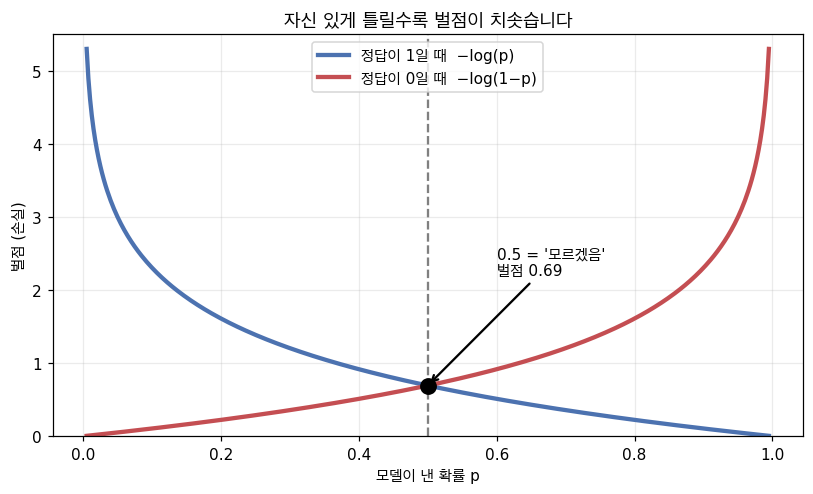

파란 선(정답이 1)을 보세요. p가 0에 가까워지면 벌점이 하늘로 솟습니다.
정답이 1인데 '0번이 확실해'라고 말한 거니까요.
반대로 p가 1에 가까우면 벌점이 0에 붙습니다.


In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
ps = np.linspace(0.005, 0.995, 400)
ax.plot(ps, -np.log(ps), lw=2.8, color="#4c72b0", label="정답이 1일 때  −log(p)")
ax.plot(ps, -np.log(1 - ps), lw=2.8, color="#c44e52", label="정답이 0일 때  −log(1−p)")
ax.axvline(0.5, color="gray", ls="--", lw=1.5)
ax.plot(0.5, -math.log(0.5), "o", ms=10, color="black", zorder=5)
ax.annotate("0.5 = '모르겠음'\n벌점 0.69", (0.5, -math.log(0.5)), xytext=(0.6, 2.2),
            fontsize=10, arrowprops=dict(arrowstyle="->", lw=1.5))
ax.set_xlabel("모델이 낸 확률 p"); ax.set_ylabel("벌점 (손실)")
ax.set_title("자신 있게 틀릴수록 벌점이 치솟습니다", fontsize=12.5)
ax.set_ylim(0, 5.5); ax.legend(fontsize=10); ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("파란 선(정답이 1)을 보세요. p가 0에 가까워지면 벌점이 하늘로 솟습니다.")
print("정답이 1인데 '0번이 확실해'라고 말한 거니까요.")
print("반대로 p가 1에 가까우면 벌점이 0에 붙습니다.")

## 4️⃣ 왜 MSE를 쓰면 안 되나

> 🔗 **앞 절과 이어서** — **3절이 왜 필요했는지, 여기가 답입니다.**
> "그냥 2단원의 MSE를 쓰면 안 되나?" 하는 의문이 당연히 들죠.
> 안 됩니다. 그 이유를 그림과 숫자로 확인합니다.

> 📗 **원문** — "You cannot use MSE for logistic regression."

원문이 이렇게 말합니다.

> **"시그모이드에 MSE를 쓰면 비용 곡면이 비볼록(non-convex)이 되어
> 지역 최솟값이 여러 개 생긴다."**

### 🧸 쉽게 말하면

2단원에서 비용 함수가 **깨끗한 밥그릇** 모양이라 공이 굴러가면 바닥에 도착했죠.

**MSE + 시그모이드를 쓰면 그릇이 울퉁불퉁해집니다.**
움푹 파인 곳이 여러 개 생겨서, 공이 **엉뚱한 웅덩이에 빠져** 멈춰 버립니다.

**크로스 엔트로피는 다시 깨끗한 그릇을 만들어 줍니다.**
그래서 어디서 시작하든 **항상 같은 정답**에 도착합니다.

> 💡 이건 7주차(Phase 1)에서 배운 **볼록성**과 정확히 같은 이야기입니다.
> Phase 1을 안 보셨어도 괜찮습니다. **"그릇이 깨끗하냐 울퉁불퉁하냐"** 로 이해하시면 됩니다.

> ✨ **추가 그림** — 두 비용 함수의 모양을 직접 비교합니다. 원문에는 설명만 있습니다.

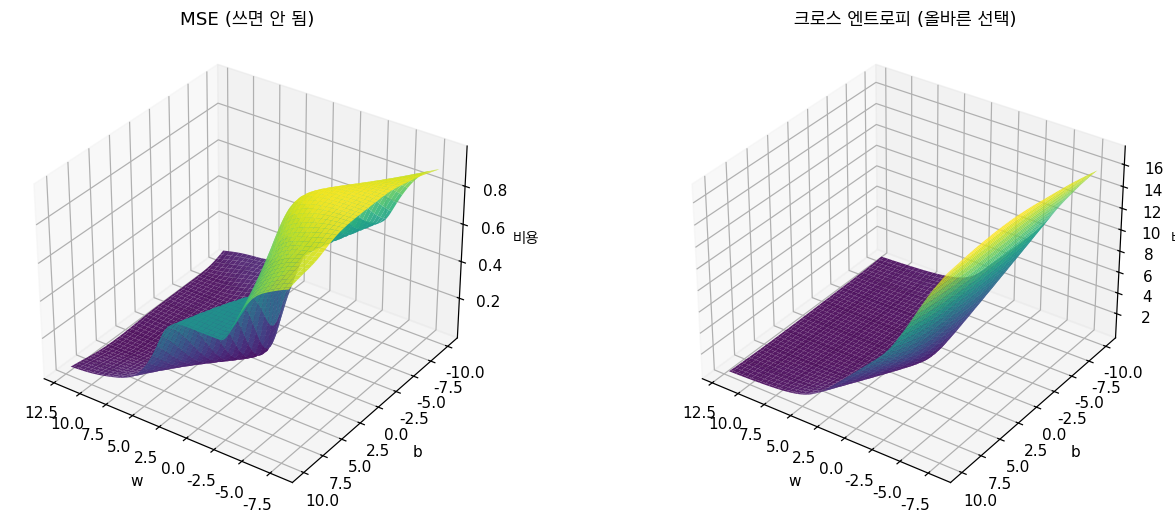

왼쪽(MSE): 넓은 평지가 있습니다. 여기 올라가면 기울기가 거의 0이라
           공이 굴러가질 않습니다. 학습이 멈춰 버려요.
오른쪽(크로스 엔트로피): 한쪽으로 계속 기울어져 있습니다.
           어디에 있든 '내려갈 방향'이 분명합니다.


In [8]:
# ✨ 추가 — 같은 데이터에 두 가지 비용 함수를 그려 비교합니다
rng = np.random.default_rng(0)
X간단 = np.r_[rng.normal(-2, 1, 40), rng.normal(2, 1, 40)]
y간단 = np.r_[np.zeros(40), np.ones(40)]

def 비용_MSE(w, b):
    p = 시그모이드(w * X간단 + b)
    return np.mean((p - y간단) ** 2)

def 비용_크로스엔트로피(w, b):
    p = np.clip(시그모이드(w * X간단 + b), 1e-12, 1 - 1e-12)
    return -np.mean(y간단 * np.log(p) + (1 - y간단) * np.log(1 - p))

fig = plt.figure(figsize=(13, 4.8))
w격자 = np.linspace(-8, 12, 90)
b격자 = np.linspace(-10, 10, 90)
W, B = np.meshgrid(w격자, b격자)

for k, (이름, 함수) in enumerate([("MSE (쓰면 안 됨)", 비용_MSE),
                                 ("크로스 엔트로피 (올바른 선택)", 비용_크로스엔트로피)]):
    Z = np.array([[함수(w, b) for w in w격자] for b in b격자])
    ax = fig.add_subplot(1, 2, k + 1, projection="3d")
    ax.plot_surface(W, B, Z, cmap="viridis", alpha=0.9)
    ax.set_xlabel("w"); ax.set_ylabel("b"); ax.set_zlabel("비용")
    ax.set_title(이름, fontsize=12)
    ax.view_init(elev=32, azim=125)

plt.tight_layout()
plt.show()

print("왼쪽(MSE): 넓은 평지가 있습니다. 여기 올라가면 기울기가 거의 0이라")
print("           공이 굴러가질 않습니다. 학습이 멈춰 버려요.")
print("오른쪽(크로스 엔트로피): 한쪽으로 계속 기울어져 있습니다.")
print("           어디에 있든 '내려갈 방향'이 분명합니다.")

In [9]:
# ✨ 추가 — 실제로 학습시켜서 차이를 확인합니다
def 학습해보기(비용종류, 시작w, 시작b, 학습률=0.5, 반복=3000):
    w, b = 시작w, 시작b
    for _ in range(반복):
        p = 시그모이드(w * X간단 + b)
        if 비용종류 == "CE":
            공통 = (p - y간단)                       # 크로스 엔트로피의 기울기 (아주 단순!)
        else:
            공통 = (p - y간단) * p * (1 - p)          # MSE는 시그모이드 미분이 곱해짐
        w -= 학습률 * np.mean(공통 * X간단) * 2
        b -= 학습률 * np.mean(공통) * 2
    정확도 = np.mean((시그모이드(w * X간단 + b) >= 0.5) == y간단)
    return w, b, 정확도

print("나쁜 출발점(w=-6, b=5)에서 학습을 시작해 봅니다\n")
print(f"{'비용 함수':>20}{'최종 w':>12}{'최종 b':>12}{'정확도':>12}")
print("-" * 58)
for 종류, 이름 in [("MSE", "MSE"), ("CE", "크로스 엔트로피")]:
    w_, b_, acc = 학습해보기(종류, -6.0, 5.0)
    print(f"{이름:>20}{w_:>12.3f}{b_:>12.3f}{acc:>11.1%}")

print("\n=> MSE는 나쁜 출발점에서 빠져나오지 못합니다.")
print("   기울기에 p(1-p)가 곱해지는데, p가 0이나 1에 가까우면 이 값이 거의 0이라")
print("   '움직일 힘'이 사라지기 때문입니다.")
print("\n   크로스 엔트로피는 기울기가 그냥 (예측 - 정답)입니다. 아주 깔끔하죠.")
print("   많이 틀릴수록 크게 움직입니다. 이게 우리가 원하는 동작입니다.")

나쁜 출발점(w=-6, b=5)에서 학습을 시작해 봅니다

               비용 함수        최종 w        최종 b         정확도
----------------------------------------------------------
                 MSE      -0.551       7.373      50.0%
            크로스 엔트로피       9.137       2.874     100.0%

=> MSE는 나쁜 출발점에서 빠져나오지 못합니다.
   기울기에 p(1-p)가 곱해지는데, p가 0이나 1에 가까우면 이 값이 거의 0이라
   '움직일 힘'이 사라지기 때문입니다.

   크로스 엔트로피는 기울기가 그냥 (예측 - 정답)입니다. 아주 깔끔하죠.
   많이 틀릴수록 크게 움직입니다. 이게 우리가 원하는 동작입니다.


## 5️⃣ 🔨 직접 만들어 보기

> 🔗 **앞 절과 이어서** — 조각이 다 모였습니다.
> **직선(2단원) + 시그모이드(1절) + 크로스 엔트로피(3절)** = 로지스틱 회귀.
> 경사하강법은 2단원에서 만든 걸 거의 그대로 씁니다.

> 📗 **원문** — "Build It: Step 2"

### 🔑 기울기가 놀랍도록 단순합니다

크로스 엔트로피를 미분하면 이렇게 나옵니다.

$$\frac{\partial \text{손실}}{\partial w} = \frac{1}{n}\sum(p - y)\,x$$

**2단원의 MSE 기울기와 모양이 똑같습니다!** (상수 2만 빠졌어요)

시그모이드의 복잡한 미분이 크로스 엔트로피의 `log`와 만나면서 **깨끗하게 약분**됩니다.
우연이 아니라, 크로스 엔트로피가 시그모이드의 짝으로 설계됐기 때문입니다.

In [10]:
class 로지스틱회귀:
    def __init__(self, 학습률=0.1):
        self.w = None
        self.b = 0.0
        self.학습률 = 학습률
        self.손실기록 = []

    def 확률예측(self, X):
        # ① 직선 계산 -> ② 시그모이드 씌우기
        z = X @ self.w + self.b
        return 시그모이드(z)

    def 예측(self, X, 임곗값=0.5):
        return (self.확률예측(X) >= 임곗값).astype(int)

    def 손실(self, X, y):
        p = np.clip(self.확률예측(X), 1e-12, 1 - 1e-12)   # log(0) 방지
        return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

    def 학습(self, X, y, 반복=2000, 출력간격=400, 조용히=False):
        self.w = np.zeros(X.shape[1])
        self.b = 0.0
        for 회차 in range(반복):
            p = self.확률예측(X)
            오차 = p - y                                  # 이게 전부입니다!
            self.w -= self.학습률 * (X.T @ 오차) / len(y)
            self.b -= self.학습률 * 오차.mean()
            self.손실기록.append(self.손실(X, y))
            if not 조용히 and 회차 % 출력간격 == 0:
                print(f"  {회차:>5}번째 | 손실 {self.손실(X,y):.4f} | "
                      f"정확도 {np.mean(self.예측(X)==y):.1%}")
        return self

# 2차원 데이터 만들기 (두 그룹)
rng = np.random.default_rng(42)
그룹0 = rng.normal([-1.5, -1.5], 1.2, size=(150, 2))
그룹1 = rng.normal([1.5, 1.5], 1.2, size=(150, 2))
X = np.vstack([그룹0, 그룹1])
y = np.r_[np.zeros(150), np.ones(150)]
섞기 = rng.permutation(len(X))
X, y = X[섞기], y[섞기]
X훈련, y훈련, X테스트, y테스트 = X[:210], y[:210], X[210:], y[210:]

print("=== 학습 시작 ===")
모델 = 로지스틱회귀(학습률=0.5).학습(X훈련, y훈련)

print(f"\n찾아낸 값: w = {모델.w},  b = {모델.b:.4f}")
print(f"훈련 정확도  : {np.mean(모델.예측(X훈련)==y훈련):.1%}")
print(f"테스트 정확도: {np.mean(모델.예측(X테스트)==y테스트):.1%}")
print(f"\n최종 손실 {모델.손실(X훈련, y훈련):.4f}  (0.69보다 한참 낮으니 잘 배웠습니다)")

=== 학습 시작 ===
      0번째 | 손실 0.3195 | 정확도 95.7%
    400번째 | 손실 0.1356 | 정확도 95.7%
    800번째 | 손실 0.1356 | 정확도 95.7%
   1200번째 | 손실 0.1356 | 정확도 95.7%
   1600번째 | 손실 0.1356 | 정확도 95.7%

찾아낸 값: w = [1.483 1.81 ],  b = 0.5709
훈련 정확도  : 95.7%
테스트 정확도: 97.8%

최종 손실 0.1356  (0.69보다 한참 낮으니 잘 배웠습니다)


## 6️⃣ 결정 경계

> 🔗 **앞 절과 이어서** — 5절에서 모델을 만들었습니다. 그런데 이 모델은 결국 **뭘 한 걸까요?**
> 확률을 뱉는다는 건 알겠는데, 그림으로 보면 **어디에 선을 그은 것**인지 확인해 봅니다.

> 📗 **원문** — "The Decision Boundary"

모델이 "여기서부터는 1번"이라고 가르는 선을 **결정 경계**라고 합니다.

시그모이드가 정확히 0.5를 뱉는 지점, 즉 **`wx + b = 0`** 인 곳입니다.

$$w_1x_1 + w_2x_2 + b = 0$$

### 🔑 이건 직선입니다

식을 정리하면 `x₂ = -(w₁x₁ + b)/w₂` 예요. **1차 함수, 즉 직선입니다.**

> **로지스틱 회귀는 직선(또는 평면)으로만 나눌 수 있습니다.**
>
> 1단원에서 본 도넛 모양 데이터는 여전히 못 나눕니다.
> 곡선 경계가 필요하면 4단원(결정 트리), 5단원(SVM)으로 가야 해요.

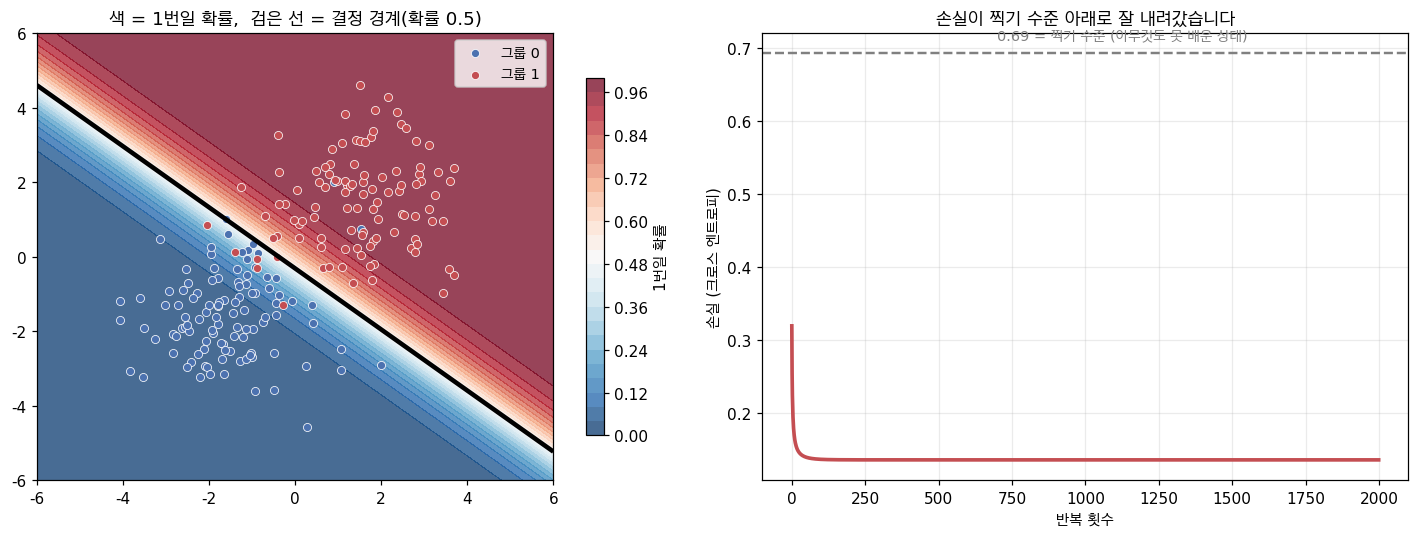

왼쪽 그림에서 색이 '점점' 변하는 걸 보세요.
경계 근처는 보라색(확률 0.5 근처, 애매함)이고, 멀어질수록 진한 색(확신)입니다.

이게 1단원의 최근접 중심 분류기와 다른 점입니다.
그건 '0번 아니면 1번'만 말했는데, 이건 '얼마나 확신하는지'까지 알려 줍니다.


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# 왼쪽: 확률 지도 + 결정 경계
gx, gy = np.meshgrid(np.linspace(-6, 6, 300), np.linspace(-6, 6, 300))
격자확률 = 모델.확률예측(np.c_[gx.ravel(), gy.ravel()]).reshape(gx.shape)
그림 = ax1.contourf(gx, gy, 격자확률, levels=25, cmap="RdBu_r", alpha=0.75)
ax1.contour(gx, gy, 격자확률, levels=[0.5], colors="black", linewidths=3)
ax1.scatter(X훈련[y훈련==0,0], X훈련[y훈련==0,1], s=28, color="#4c72b0",
            edgecolor="white", linewidth=0.5, label="그룹 0")
ax1.scatter(X훈련[y훈련==1,0], X훈련[y훈련==1,1], s=28, color="#c44e52",
            edgecolor="white", linewidth=0.5, label="그룹 1")
ax1.set_title("색 = 1번일 확률,  검은 선 = 결정 경계(확률 0.5)", fontsize=12)
ax1.legend(fontsize=9.5); ax1.set_xlim(-6, 6); ax1.set_ylim(-6, 6)
plt.colorbar(그림, ax=ax1, shrink=0.8, label="1번일 확률")

# 오른쪽: 손실이 줄어드는 모습
ax2.plot(모델.손실기록, lw=2.4, color="#c44e52")
ax2.axhline(math.log(2), color="gray", ls="--", lw=1.6)
ax2.text(len(모델.손실기록)*0.35, math.log(2)+0.02,
         "0.69 = 찍기 수준 (아무것도 못 배운 상태)", fontsize=9.5, color="gray")
ax2.set_xlabel("반복 횟수"); ax2.set_ylabel("손실 (크로스 엔트로피)")
ax2.set_title("손실이 찍기 수준 아래로 잘 내려갔습니다", fontsize=12)
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("왼쪽 그림에서 색이 '점점' 변하는 걸 보세요.")
print("경계 근처는 보라색(확률 0.5 근처, 애매함)이고, 멀어질수록 진한 색(확신)입니다.")
print("\n이게 1단원의 최근접 중심 분류기와 다른 점입니다.")
print("그건 '0번 아니면 1번'만 말했는데, 이건 '얼마나 확신하는지'까지 알려 줍니다.")

## 7️⃣ 혼동 행렬 · 정밀도 · 재현율 · F1

> 🔗 **여기서 방향이 바뀝니다** — 6절까지는 "어떻게 만드나"였습니다.
> 지금부터는 **"만든 걸 어떻게 평가하나"**입니다. 그리고 여기서 함정을 하나 만납니다.
> **정확도 하나만 보면 완전히 속을 수 있습니다.**

> 📗 **원문** — "Evaluation Metrics"

### ⚠️ 정확도만 보면 속습니다

원문 표현을 그대로 옮기면 이렇습니다.

> **"음성 95%, 양성 5%인 데이터에서 '항상 음성'이라고 답하는 모델은
> 정확도 95%를 얻지만 아무 쓸모가 없다."**

1단원 8절의 "기준선과 비교하라"가 여기서 다시 나옵니다.

### 📐 혼동 행렬 — 네 칸으로 나눠 보기

| | **1번이라 예측** | **0번이라 예측** |
| --- | --- | --- |
| **실제 1번** | TP (맞게 잡음) | **FN (놓침)** |
| **실제 0번** | **FP (헛짚음)** | TN (맞게 넘김) |

### 🧸 화재경보기로 이해하기

- **TP**: 불이 났고 경보가 울림 ✅
- **TN**: 불이 안 났고 경보도 안 울림 ✅
- **FP (헛짚음)**: **불이 안 났는데 경보가 울림** — 시끄럽고 짜증남
- **FN (놓침)**: **불이 났는데 경보가 안 울림** — 사람이 죽음

**두 실수의 무게가 완전히 다릅니다.** 그래서 지표가 여러 개 필요해요.

### 📐 세 가지 지표

$$\text{정밀도} = \frac{TP}{TP + FP} \qquad \text{"경보가 울렸을 때, 진짜 불일 확률"}$$

$$\text{재현율} = \frac{TP}{TP + FN} \qquad \text{"진짜 불 중에서, 경보가 잡아낸 비율"}$$

$$F_1 = \frac{2 \times \text{정밀도} \times \text{재현율}}{\text{정밀도} + \text{재현율}}$$

### 🔑 언제 뭘 중요하게 보나

| 상황 | 중요한 지표 | 이유 |
| --- | --- | --- |
| **스팸 필터** | **정밀도** | 중요한 메일을 스팸함에 넣으면 큰일 (FP가 치명적) |
| **암 검진** | **재현율** | 암을 놓치면 사람이 죽음 (FN이 치명적) |
| **균형이 필요** | **F1** | 둘 다 적당히 챙기고 싶을 때 |

In [12]:
def 혼동행렬(실제, 예측):
    TP = int(np.sum((실제 == 1) & (예측 == 1)))
    TN = int(np.sum((실제 == 0) & (예측 == 0)))
    FP = int(np.sum((실제 == 0) & (예측 == 1)))
    FN = int(np.sum((실제 == 1) & (예측 == 0)))
    return TP, TN, FP, FN

def 지표계산(실제, 예측):
    TP, TN, FP, FN = 혼동행렬(실제, 예측)
    정확도 = (TP + TN) / len(실제)
    정밀도 = TP / (TP + FP) if TP + FP else 0.0
    재현율 = TP / (TP + FN) if TP + FN else 0.0
    F1 = 2 * 정밀도 * 재현율 / (정밀도 + 재현율) if 정밀도 + 재현율 else 0.0
    return 정확도, 정밀도, 재현율, F1

예측 = 모델.예측(X테스트)
TP, TN, FP, FN = 혼동행렬(y테스트, 예측)

print("우리 모델의 혼동 행렬 (테스트 데이터)\n")
print(f"{'':>16}{'1번이라 예측':>16}{'0번이라 예측':>16}")
print(f"{'실제 1번':>14}{TP:>14} (TP){FN:>12} (FN)")
print(f"{'실제 0번':>14}{FP:>14} (FP){TN:>12} (TN)")

정확도, 정밀도, 재현율, F1 = 지표계산(y테스트, 예측)
print(f"\n{'지표':>12}{'값':>10}   설명")
print("-" * 60)
print(f"{'정확도':>12}{정확도:>10.1%}   전체 중 맞힌 비율")
print(f"{'정밀도':>12}{정밀도:>10.1%}   1번이라 한 것 중 진짜 1번인 비율")
print(f"{'재현율':>12}{재현율:>10.1%}   진짜 1번 중 잡아낸 비율")
print(f"{'F1':>12}{F1:>10.1%}   정밀도와 재현율의 균형")

우리 모델의 혼동 행렬 (테스트 데이터)

                         1번이라 예측         0번이라 예측
         실제 1번            43 (TP)           2 (FN)
         실제 0번             0 (FP)          45 (TN)

          지표         값   설명
------------------------------------------------------------
         정확도     97.8%   전체 중 맞힌 비율
         정밀도    100.0%   1번이라 한 것 중 진짜 1번인 비율
         재현율     95.6%   진짜 1번 중 잡아낸 비율
          F1     97.7%   정밀도와 재현율의 균형


> ✨ **추가 실험** — '정확도만 보면 속는다'를 직접 확인합니다.

In [13]:
# ✨ 추가 — 불균형 데이터(양성 5%)를 만들어 봅니다
rng2 = np.random.default_rng(7)
n정상, n환자 = 950, 50
정상데이터 = rng2.normal([0, 0], 1.0, size=(n정상, 2))
환자데이터 = rng2.normal([2.2, 2.2], 1.0, size=(n환자, 2))
X불균형 = np.vstack([정상데이터, 환자데이터])
y불균형 = np.r_[np.zeros(n정상), np.ones(n환자)]

print(f"암 검진 데이터: 정상 {n정상}명, 환자 {n환자}명 (환자가 {n환자/1000:.0%})\n")

# 게으른 모델: 무조건 '정상'이라고 답함
게으른예측 = np.zeros(len(y불균형))
# 우리 모델
진짜모델 = 로지스틱회귀(학습률=0.5).학습(X불균형, y불균형, 반복=3000, 조용히=True)
모델예측 = 진짜모델.예측(X불균형)

print(f"{'모델':>26}{'정확도':>10}{'정밀도':>10}{'재현율':>10}{'F1':>10}")
print("-" * 68)
for 이름, 예측_ in [("① 무조건 '정상'이라 답하기", 게으른예측),
                   ("② 로지스틱 회귀", 모델예측)]:
    a, p, r, f = 지표계산(y불균형, 예측_)
    print(f"{이름:>24}{a:>10.1%}{p:>10.1%}{r:>10.1%}{f:>10.1%}")

print("\n=> ①번은 정확도가 95%입니다! 숫자만 보면 훌륭해 보이죠.")
print("   그런데 재현율이 0%입니다. 환자를 '단 한 명도' 못 찾았어요.")
print("   암 검진에서 이건 최악의 모델입니다.")
print("\n   ⚠️ 정확도 하나만 보고했다면 아무도 이 사실을 몰랐을 겁니다.")
print("      그래서 분류 문제에서는 '항상' 정밀도와 재현율을 함께 봐야 합니다.")

암 검진 데이터: 정상 950명, 환자 50명 (환자가 5%)

                        모델       정확도       정밀도       재현율        F1
--------------------------------------------------------------------
        ① 무조건 '정상'이라 답하기     95.0%      0.0%      0.0%      0.0%
               ② 로지스틱 회귀     97.9%     83.7%     72.0%     77.4%

=> ①번은 정확도가 95%입니다! 숫자만 보면 훌륭해 보이죠.
   그런데 재현율이 0%입니다. 환자를 '단 한 명도' 못 찾았어요.
   암 검진에서 이건 최악의 모델입니다.

   ⚠️ 정확도 하나만 보고했다면 아무도 이 사실을 몰랐을 겁니다.
      그래서 분류 문제에서는 '항상' 정밀도와 재현율을 함께 봐야 합니다.


## 8️⃣ 임곗값 조절하기

> 🔗 **앞 절과 이어서** — 7절에서 정밀도와 재현율이 **서로 밀고 당긴다**는 걸 봤습니다.
> 그럼 **어느 쪽을 더 중요하게 볼지 내가 정할 수 있을까요?** 있습니다.
> 그동안 아무 생각 없이 쓰던 **0.5라는 기준선**을 움직이면 됩니다.

> 📗 **원문** — "Step 6: Threshold tuning"

지금까지 **0.5를 기준**으로 판정했습니다. 그런데 **이 값은 바꿀 수 있습니다.**

- **임곗값을 낮추면** (예: 0.3) → 더 쉽게 "1번"이라고 함 → **재현율↑, 정밀도↓**
- **임곗값을 높이면** (예: 0.7) → 확실할 때만 "1번" → **정밀도↑, 재현율↓**

### 🧸 화재경보기 감도 조절

- **민감하게** 맞추면: 작은 연기에도 울림 → 불은 절대 안 놓침(재현율↑) 但 오작동 많음(정밀도↓)
- **둔감하게** 맞추면: 확실할 때만 울림 → 오작동 적음(정밀도↑) 但 놓칠 수 있음(재현율↓)

> 🔑 **모델을 다시 학습시킬 필요가 없습니다.** 판정 기준만 바꾸면 됩니다.
> 같은 모델로 "안전 우선"과 "정확도 우선"을 오갈 수 있어요.

In [14]:
print("임곗값을 바꿔 가며 지표 변화를 봅니다 (암 검진 데이터)\n")
print(f"{'임곗값':>10}{'정확도':>10}{'정밀도':>10}{'재현율':>10}{'F1':>10}{'특징':>22}")
print("-" * 74)
결과들 = []
for 임곗값 in [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]:
    예측_ = 진짜모델.예측(X불균형, 임곗값=임곗값)
    a, p, r, f = 지표계산(y불균형, 예측_)
    결과들.append((임곗값, p, r, f))
    특징 = ("놓치지 않기 우선" if 임곗값 < 0.5 else
            "기본값 (균형)" if 임곗값 == 0.5 else "헛짚지 않기 우선")
    print(f"{임곗값:>10.1f}{a:>10.1%}{p:>10.1%}{r:>10.1%}{f:>10.1%}{특징:>22}")

최고F1 = max(결과들, key=lambda r: r[3])
낮은값 = 결과들[0]
높은값 = 결과들[-1]
print(f"\n=> 임곗값을 {낮은값[0]}에서 {높은값[0]}로 올리면")
print(f"     재현율 {낮은값[2]:.0%} -> {높은값[2]:.0%}  (놓치는 환자가 늘어남)")
print(f"     정밀도 {낮은값[1]:.0%} -> {높은값[1]:.0%}  (헛짚는 일은 줄어듦)")
print(f"\n   F1이 가장 높은 값은 {최고F1[0]}입니다.")
print("   하지만 '무조건 F1 최고값'을 골라야 하는 건 아닙니다.")
print("\n   암 검진이라면 재현율이 중요하니 임곗값을 낮게 잡아야 합니다.")
print("   환자를 놓치는 것(FN)이 헛짚는 것(FP)보다 훨씬 위험하니까요.")
print("   => 이건 수학 문제가 아니라 '무엇이 더 위험한가'라는 판단의 문제입니다.")

임곗값을 바꿔 가며 지표 변화를 봅니다 (암 검진 데이터)

       임곗값       정확도       정밀도       재현율        F1                    특징
--------------------------------------------------------------------------
       0.1     96.0%     56.2%     90.0%     69.2%             놓치지 않기 우선
       0.2     96.9%     64.2%     86.0%     73.5%             놓치지 않기 우선
       0.3     97.6%     72.4%     84.0%     77.8%             놓치지 않기 우선
       0.5     97.9%     83.7%     72.0%     77.4%              기본값 (균형)
       0.7     97.7%     93.5%     58.0%     71.6%             헛짚지 않기 우선
       0.9     97.0%    100.0%     40.0%     57.1%             헛짚지 않기 우선

=> 임곗값을 0.1에서 0.9로 올리면
     재현율 90% -> 40%  (놓치는 환자가 늘어남)
     정밀도 56% -> 100%  (헛짚는 일은 줄어듦)

   F1이 가장 높은 값은 0.3입니다.
   하지만 '무조건 F1 최고값'을 골라야 하는 건 아닙니다.

   암 검진이라면 재현율이 중요하니 임곗값을 낮게 잡아야 합니다.
   환자를 놓치는 것(FN)이 헛짚는 것(FP)보다 훨씬 위험하니까요.
   => 이건 수학 문제가 아니라 '무엇이 더 위험한가'라는 판단의 문제입니다.


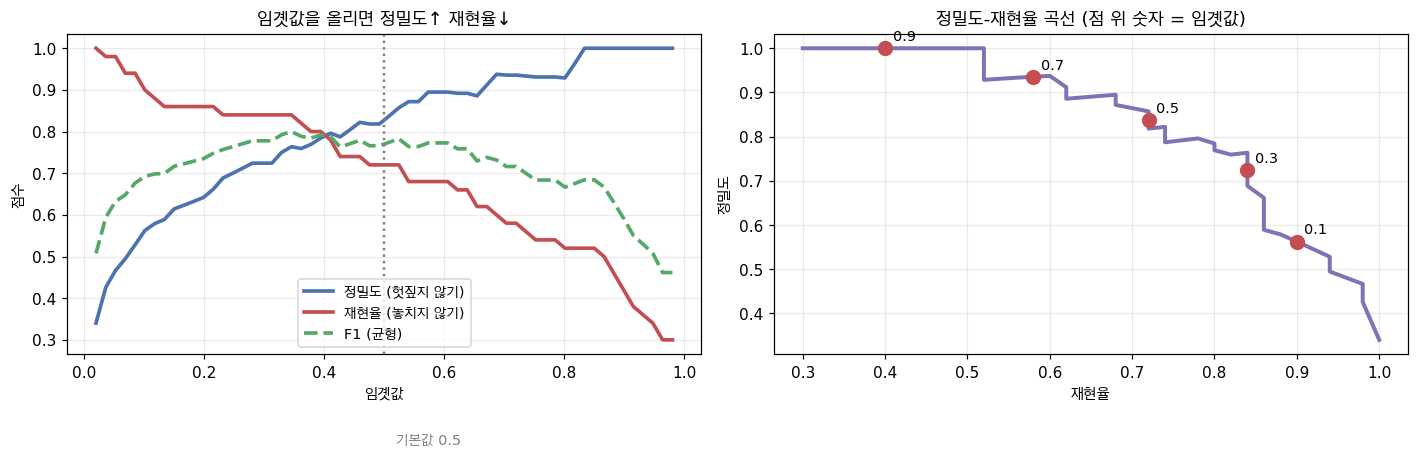

왼쪽: 파란 선과 빨간 선이 시소처럼 움직입니다. 하나를 올리면 하나가 내려가요.
오른쪽: 이 시소 관계를 한 곡선으로 나타낸 것입니다.
        오른쪽 위 구석에 가까울수록 좋은 모델입니다.


In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))

임곗값들 = np.linspace(0.02, 0.98, 60)
정밀도들, 재현율들, F1들 = [], [], []
for t in 임곗값들:
    _, p, r, f = 지표계산(y불균형, 진짜모델.예측(X불균형, 임곗값=t))
    정밀도들.append(p); 재현율들.append(r); F1들.append(f)

ax1.plot(임곗값들, 정밀도들, lw=2.4, color="#4c72b0", label="정밀도 (헛짚지 않기)")
ax1.plot(임곗값들, 재현율들, lw=2.4, color="#c44e52", label="재현율 (놓치지 않기)")
ax1.plot(임곗값들, F1들, lw=2.4, color="#55a868", ls="--", label="F1 (균형)")
ax1.axvline(0.5, color="gray", ls=":", lw=1.6)
ax1.text(0.52, 0.05, "기본값 0.5", fontsize=9.5, color="gray")
ax1.set_xlabel("임곗값"); ax1.set_ylabel("점수")
ax1.set_title("임곗값을 올리면 정밀도↑ 재현율↓", fontsize=12)
ax1.legend(fontsize=9.5); ax1.grid(alpha=0.25)

ax2.plot(재현율들, 정밀도들, lw=2.6, color="#8172b3")
for t in [0.1, 0.3, 0.5, 0.7, 0.9]:
    _, p, r, _ = 지표계산(y불균형, 진짜모델.예측(X불균형, 임곗값=t))
    ax2.plot(r, p, "o", ms=9, color="#c44e52", zorder=5)
    ax2.annotate(f"{t}", (r, p), xytext=(5, 5), textcoords="offset points", fontsize=9.5)
ax2.set_xlabel("재현율"); ax2.set_ylabel("정밀도")
ax2.set_title("정밀도-재현율 곡선 (점 위 숫자 = 임곗값)", fontsize=12)
ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("왼쪽: 파란 선과 빨간 선이 시소처럼 움직입니다. 하나를 올리면 하나가 내려가요.")
print("오른쪽: 이 시소 관계를 한 곡선으로 나타낸 것입니다.")
print("        오른쪽 위 구석에 가까울수록 좋은 모델입니다.")

## 9️⃣ 여러 종류로 나누기 (소프트맥스)

> 🔗 **앞 절과 이어서** — 여기까지 전부 **둘 중 하나**(스팸/정상)였습니다.
> 숫자 0~9를 알아맞히려면? **10개 중 하나**를 골라야 합니다.
> 1절의 시그모이드를 **여러 개짜리로 확장**하면 됩니다.

> 📗 **원문** — "Multi-Class Classification with Softmax"

지금까지는 **둘 중 하나**였습니다. 그럼 **셋 이상**은 어떻게 할까요?

**소프트맥스**를 씁니다. 시그모이드의 여러 개 버전이에요.

$$p_i = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

### 🧸 말로 풀면

1. 각 종류마다 **점수**를 계산합니다 (`z₁`, `z₂`, `z₃`)
2. 각 점수를 **`e`의 지수로** 만듭니다 (전부 양수가 됨)
3. **전체 합으로 나눕니다** (전부 더하면 1이 됨)

> **결과: 각 종류일 확률. 다 더하면 정확히 1.**

### 🔑 시그모이드와의 관계

**종류가 2개일 때 소프트맥스 = 시그모이드**입니다.
소프트맥스가 더 일반적인 버전이에요.

In [16]:
def 소프트맥스(z):
    # 가장 큰 값을 빼서 exp가 폭발하지 않게 합니다 (결과는 같습니다)
    z = z - np.max(z, axis=-1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=-1, keepdims=True)

print("점수 3개를 확률로 바꿔 봅니다\n")
예시들 = [
    ("확실한 경우", np.array([5.0, 1.0, 0.5])),
    ("애매한 경우", np.array([2.0, 1.9, 1.8])),
    ("완전 모름", np.array([1.0, 1.0, 1.0])),
]
for 이름, 점수 in 예시들:
    확률 = 소프트맥스(점수)
    print(f"  [{이름}]  점수 {점수}")
    print(f"     -> 확률 {np.round(확률, 4)}   합계 {확률.sum():.6f}")
    print(f"     -> 예측: {int(np.argmax(확률))}번  (확신도 {확률.max():.1%})\n")

print("=> 어떤 경우든 확률의 합이 정확히 1입니다.")
print("   점수 차이가 클수록 한쪽에 확률이 몰리고, 비슷하면 고루 퍼집니다.")

print("\n【 종류가 2개면 시그모이드와 같은지 확인 】")
for z차이 in [-2.0, 0.0, 1.5, 3.0]:
    소맥 = 소프트맥스(np.array([z차이, 0.0]))[0]
    시그 = float(시그모이드(np.array([z차이]))[0])
    print(f"  z차이 {z차이:>5}: 소프트맥스 {소맥:.6f}  시그모이드 {시그:.6f}  "
          f"차이 {abs(소맥-시그):.1e}")
print("\n  => 완전히 같습니다. 시그모이드는 소프트맥스의 2개짜리 특수한 경우입니다.")

점수 3개를 확률로 바꿔 봅니다

  [확실한 경우]  점수 [5.  1.  0.5]
     -> 확률 [0.971 0.018 0.011]   합계 1.000000
     -> 예측: 0번  (확신도 97.1%)

  [애매한 경우]  점수 [2.  1.9 1.8]
     -> 확률 [0.367 0.332 0.301]   합계 1.000000
     -> 예측: 0번  (확신도 36.7%)

  [완전 모름]  점수 [1. 1. 1.]
     -> 확률 [0.333 0.333 0.333]   합계 1.000000
     -> 예측: 0번  (확신도 33.3%)

=> 어떤 경우든 확률의 합이 정확히 1입니다.
   점수 차이가 클수록 한쪽에 확률이 몰리고, 비슷하면 고루 퍼집니다.

【 종류가 2개면 시그모이드와 같은지 확인 】
  z차이  -2.0: 소프트맥스 0.119203  시그모이드 0.119203  차이 0.0e+00
  z차이   0.0: 소프트맥스 0.500000  시그모이드 0.500000  차이 0.0e+00
  z차이   1.5: 소프트맥스 0.817574  시그모이드 0.817574  차이 0.0e+00
  z차이   3.0: 소프트맥스 0.952574  시그모이드 0.952574  차이 0.0e+00

  => 완전히 같습니다. 시그모이드는 소프트맥스의 2개짜리 특수한 경우입니다.


## 🔟 용어 사전 · 연습문제

> 📗 **원문** — "Key Terms" · "Exercises"

### 용어 사전

| 용어 | 사람들이 하는 말 | 진짜 뜻 |
| --- | --- | --- |
| **로지스틱 회귀** | "예/아니오 맞히기" | 직선에 시그모이드를 씌워 확률을 내는 분류 모델 |
| **시그모이드** | "S자 곡선" | `1/(1+e⁻ᶻ)`. 어떤 숫자든 0~1 사이로 눌러 담음 |
| **크로스 엔트로피** | "로그 손실" | 정답에 준 확률에 `−log`를 씌운 벌점. 자신 있게 틀리면 폭탄 |
| **결정 경계** | "가르는 선" | 확률이 0.5가 되는 지점. `wx+b=0` |
| **혼동 행렬** | "네 칸 표" | TP/TN/FP/FN을 정리한 표 |
| **정밀도** | "헛짚지 않기" | `TP/(TP+FP)`. 1번이라 한 것 중 진짜 비율 |
| **재현율** | "놓치지 않기" | `TP/(TP+FN)`. 진짜 1번 중 잡아낸 비율 |
| **F1 점수** | "균형 점수" | 정밀도와 재현율의 조화평균 |
| **임곗값** | "판정 기준" | 확률이 얼마 이상이면 1번이라 할지. 기본 0.5, 바꿀 수 있음 |
| **소프트맥스** | "여러 개짜리 시그모이드" | 점수들을 합이 1인 확률로 바꿈. 3종류 이상일 때 |

---

### 연습문제

**1.** 시그모이드에 `z = 0, ±1, ±5, ±100`을 넣어 보세요.
왜 `z`가 커져도 1을 넘지 않는지 식을 보고 설명해 보세요.

**2.** 크로스 엔트로피에서 **정답에 0.5를 준 경우**의 손실을 손으로 계산해 보세요.
왜 이 값(0.69)이 "아무것도 못 배운 상태"의 기준이 되나요?

**3.** 7절의 암 검진 데이터에서 임곗값을 0.1로 낮춰 보세요.
- 재현율은 얼마나 올라가나요?
- 그 대가로 정밀도는 얼마나 떨어지나요?
- 실제 병원이라면 어떤 값을 고르시겠어요? **왜죠?**

**4.** 스팸 필터를 만든다면 임곗값을 **높게** 잡아야 할까요, **낮게** 잡아야 할까요?
7절의 표를 다시 보고 답해 보세요.

---

## 🎯 이 단원 한 문장 정리

> **로지스틱 회귀 = 2단원의 직선 + 시그모이드 + 크로스 엔트로피.
> 딱 두 군데만 바꿨는데 "숫자 예측"이 "예/아니오 판정"이 됐습니다.**

### 2단원과 비교하며 정리

| 단계 | 2단원 | 3단원 | 바뀌었나 |
| --- | --- | --- | --- |
| ① 모델 | `wx + b` | `시그모이드(wx + b)` | **바뀜** |
| ② 비용 | MSE | 크로스 엔트로피 | **바뀜** |
| ③ 최적화 | 경사하강법 | 경사하강법 | 그대로 |
| 기울기 | `(예측−정답)·x` | `(예측−정답)·x` | **그대로!** |

마지막 줄이 재미있습니다. 모델과 비용을 둘 다 바꿨는데
**기울기 공식은 똑같이 나옵니다.** 시그모이드와 크로스 엔트로피가 서로의 짝이라서요.

### 꼭 기억할 것

1. **시그모이드는 압축기**입니다. 무한한 숫자를 0~1로 눌러 담습니다
2. **손실 0.69는 "찍기 수준"** 입니다. 여기서 안 내려가면 학습이 안 되는 겁니다
3. **정확도만 보면 속습니다.** 정밀도와 재현율을 함께 보세요
4. **임곗값은 재학습 없이 바꿀 수 있습니다.** "무엇이 더 위험한가"에 따라 정하세요

### 다음 단원 예고

4단원 **결정 트리**에서는 **곡선 경계**를 그릴 수 있는 모델을 배웁니다.
로지스틱 회귀가 못 나누던 도넛 모양 데이터를 드디어 다룰 수 있게 됩니다.

---

## 📖 더 읽을거리

> 📗 **원문** — "Further Reading"

- [scikit-learn 로지스틱 회귀 문서](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression)
- [Google ML Crash Course: 로지스틱 회귀](https://developers.google.com/machine-learning/crash-course/logistic-regression) (한국어 지원)
- [분류 지표 정리 (scikit-learn)](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics)